In [1]:
# Imports and setup
import sys
from pathlib import Path
sys.path.append(str(Path('../../src').resolve()))

import os, random
import warnings
import time
import traceback
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Bidirectional,
                                     Conv1D, Flatten, Input, Attention, GlobalAveragePooling1D)
from tensorflow.keras import backend as K

# Configure logger
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger('nb005_run_all_lstm')

# Import configs and utils
from utils.lstm_configs import LSTM_CONFIGS
from utils.variants import VARIANT_DEFS, apply_variant
from utils.eval_metrics import evaluate_model 

warnings.filterwarnings('ignore')

In [2]:
SEED = 1
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DATA_PATH = Path('../../data/out/dataset_final.csv')
VARIANTS = [(v['name'], v) for v in VARIANT_DEFS]

for vname, vdef in VARIANTS:
    print(vname, '-> base data exists?', BASE_DATA_PATH.exists())

TARGET_COLUMN = 'PRECIO'
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO", "DIA_SEMANA", "FESTIVO"]

print('Configured TARGET_COLUMN and categorical_numeric. Data will be loaded per-variant inside the runner.')

v1_original -> base data exists? True
v1_original_lags -> base data exists? True
v2_with_calendar -> base data exists? True
v2_with_calendar_lags -> base data exists? True
v3_no_solar -> base data exists? True
v3_no_solar_lags -> base data exists? True
v4_no_fuel_consumption -> base data exists? True
v4_no_fuel_consumption_lags -> base data exists? True
v5_no_fuel_and_cost -> base data exists? True
v5_no_fuel_and_cost_lags -> base data exists? True
v6_no_econ_fuel_cost -> base data exists? True
v6_no_econ_fuel_cost_lags -> base data exists? True
v7_only_gen_enso -> base data exists? True
v7_only_gen_enso_lags -> base data exists? True
v8_only_gen_no_solar_enso -> base data exists? True
v8_only_gen_no_solar_enso_lags -> base data exists? True
v9_date_range_all -> base data exists? True
v9_date_range_all_lags -> base data exists? True
v10_date_range_no_solar -> base data exists? True
v10_date_range_no_solar_lags -> base data exists? True
Configured TARGET_COLUMN and categorical_numeric. 

In [3]:
def _prepare_variant_data_for_lstm(df, target_column='PRECIO', timesteps=24,
                                   categorical_numeric=["YEAR","MONTH","DAY","HORA","NIVEL_ENSO","DIA_SEMANA","FESTIVO"]):
    df = df.drop(columns=['FECHA_HORA'], errors='ignore')

    # Separate numeric vs categorical
    numeric_cols = [c for c in df.columns if c not in categorical_numeric + [target_column]]
    X_num = df[numeric_cols].values.astype('float32') if numeric_cols else None
    X_cat = df[[c for c in categorical_numeric if c in df.columns]].values.astype('float32')
    y = df[target_column].values.astype('float32')

    # Scale only numeric features
    if X_num is not None:
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        X_num_scaled = scaler.fit_transform(X_num)
        X_all = np.concatenate([X_num_scaled, X_cat], axis=1)
    else:
        X_all = X_cat

    # Build sequences
    X_seq, y_seq = [], []
    for i in range(len(X_all) - timesteps):
        X_seq.append(X_all[i:i+timesteps, :])
        y_seq.append(y[i+timesteps])
    X_seq, y_seq = np.array(X_seq), np.array(y_seq)

    train_size = int(len(X_seq) * 0.8)
    return X_seq[:train_size], X_seq[train_size:], y_seq[:train_size], y_seq[train_size:]

In [4]:
def build_lstm(input_shape, config):
    """
    Build an LSTM model according to the given configuration.
    Supports: stacked LSTM, bidirectional, CNN+LSTM, Attention.
    """

    model = None  # placeholder

    # CNN + LSTM case (Sequential)
    if "conv1d" in config:
        model = Sequential()
        conv = config["conv1d"]
        model.add(Conv1D(filters=conv["filters"],
                         kernel_size=conv["kernel_size"],
                         activation=conv["activation"],
                         input_shape=input_shape))
        model.add(Flatten())
        for units in config["lstm_layers"]:
            model.add(Dense(units, activation="relu"))
        if config.get("dropout", 0) > 0:
            model.add(Dropout(config["dropout"]))
        model.add(Dense(1))

    # Attention case (Functional API)
    elif config.get("attention", False):
        inputs = Input(shape=input_shape)
        x = LSTM(config["layers"][0], return_sequences=True)(inputs)
        context = Attention()([x, x])
        context = GlobalAveragePooling1D()(context) 

        if config.get("dropout", 0) > 0:
            context = Dropout(config["dropout"])(context)
        outputs = Dense(1)(context)
        model = Model(inputs, outputs)


    # Standard LSTM / BiLSTM (Sequential)
    else:
        model = Sequential()
        for i, units in enumerate(config["layers"]):
            return_sequences = i < len(config["layers"]) - 1
            if config.get("bidirectional", False):
                model.add(Bidirectional(
                    LSTM(units,
                         return_sequences=return_sequences,
                         recurrent_dropout=config.get("recurrent_dropout", 0.0)),
                    input_shape=input_shape))
            else:
                model.add(LSTM(units,
                               return_sequences=return_sequences,
                               recurrent_dropout=config.get("recurrent_dropout", 0.0),
                               input_shape=input_shape))
            if config.get("dropout", 0) > 0:
                model.add(Dropout(config["dropout"]))
        model.add(Dense(1))

    # Compile once at the end
    model.compile(optimizer=config["optimizer"], loss="mse")
    return model

In [5]:
def run_lstm(config, *, variant, df, timesteps=24):
    """
    Train and evaluate an LSTM model for a given variant and configuration.
    """
    if df is None:
        raise ValueError("df must be provided")

    X_train, X_test, y_train, y_test = _prepare_variant_data_for_lstm(df, timesteps=timesteps)

    result = {"model": "LSTM", "config": config["name"], "variant": variant}
    start_time = time.time()

    try:
        model = build_lstm((X_train.shape[1], X_train.shape[2]), config)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            verbose=0
        )

        #y_pred = model.predict(X_test).ravel()
        metrics = evaluate_model(model, X_test, y_test)
        result.update(metrics)
        result["status"] = "trained"

    except Exception as e:
        tb = traceback.format_exc()
        logger.error(f"Error training LSTM {config['name']} on variant {variant}: {e}\n{tb}")
        result["status"] = "error"
        result["error"] = str(e)
        result["traceback"] = tb

    finally:
        elapsed = time.time() - start_time
        result["n_total"] = len(y_train) + len(y_test)
        result["n_train"] = len(y_train)
        result["n_test"] = len(y_test)
        result["train_time_s"] = elapsed

    return result

In [6]:
all_results = []

# Outer loop over variants with progress bar
for vname, vdef in tqdm(VARIANTS, desc="Variants"):
    logger.info(f"Processing variant {vname}")
    df_v, vmeta = apply_variant(pd.read_csv(BASE_DATA_PATH), vdef, date_col="FECHA_HORA")

    # Inner loop over LSTM configs with nested progress bar
    for config in tqdm(LSTM_CONFIGS, desc=f"Configs for {vname}", leave=False):
        res = run_lstm(config, variant=vname, df=df_v, timesteps=24)
        all_results.append(res)

results_df = pd.DataFrame(all_results)
results_df.head()

Variants:   0%|          | 0/20 [00:00<?, ?it/s]

2025-10-25 00:18:48,923 INFO Processing variant v1_original


Configs for v1_original:   0%|          | 0/6 [00:00<?, ?it/s]

2025-10-25 00:18:49,416 WARNING From c:\Users\Camilo\anaconda3\envs\env_tf\Lib\site-packages\keras\src\backend.py:873: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.



2025-10-25 00:18:49,849 WARNING From c:\Users\Camilo\anaconda3\envs\env_tf\Lib\site-packages\keras\src\optimizers\__init__.py:309: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.



...

82/82 [==============================] - 1s 7ms/step


2025-10-26 02:44:42,009 INFO Processing variant v10_date_range_no_solar_lags


Configs for v10_date_range_no_solar_lags:   0%|          | 0/6 [00:00<?, ?it/s]

82/82 [==============================] - 1s 4ms/step


,model,config,variant,R2,MAE,MSE,RMSE,MAPE(%),status,n_total,n_train,n_test,train_time_s
0,LSTM,lstm_simple,v1_original,-0.182543,353.147095,297311.781250,545.263062,83.799386,trained,48168,38534,9634,302.214905
1,LSTM,lstm_deep,v1_original,-0.179335,352.976959,296505.406250,544.523071,84.249759,trained,48168,38534,9634,2794.705111
2,LSTM,lstm_bidirectional,v1_original,-0.163415,349.068085,292502.687500,540.835205,84.412795,trained,48168,38534,9634,1213.408828
3,LSTM,bilstm_stacked,v1_original,-0.177490,352.879242,296041.593750,544.097046,84.510773,trained,48168,38534,9634,3486.919101
4,LSTM,cnn_lstm,v1_original,0.455197,220.097488,136973.046875,370.098694,104.503226,trained,48168,38534,9634,134.571223


In [7]:
# Ensure output directory exists
out_path = Path("../../data/out/lstm_results")
out_path.mkdir(parents=True, exist_ok=True)

# Save results
results_df.to_excel(out_path / "lstm_summary.xlsx", index=False)
results_df.head()

,model,config,variant,R2,MAE,MSE,RMSE,MAPE(%),status,n_total,n_train,n_test,train_time_s
0,LSTM,lstm_simple,v1_original,-0.182543,353.147095,297311.781250,545.263062,83.799386,trained,48168,38534,9634,302.214905
1,LSTM,lstm_deep,v1_original,-0.179335,352.976959,296505.406250,544.523071,84.249759,trained,48168,38534,9634,2794.705111
2,LSTM,lstm_bidirectional,v1_original,-0.163415,349.068085,292502.687500,540.835205,84.412795,trained,48168,38534,9634,1213.408828
3,LSTM,bilstm_stacked,v1_original,-0.177490,352.879242,296041.593750,544.097046,84.510773,trained,48168,38534,9634,3486.919101
4,LSTM,cnn_lstm,v1_original,0.455197,220.097488,136973.046875,370.098694,104.503226,trained,48168,38534,9634,134.571223


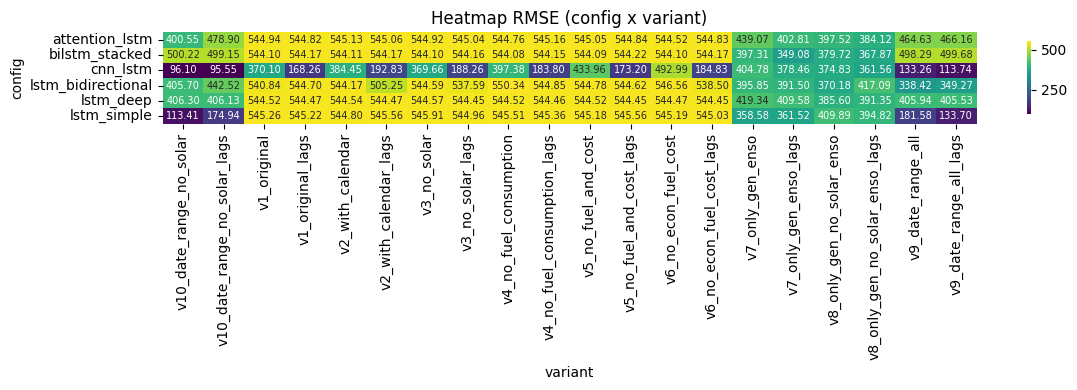

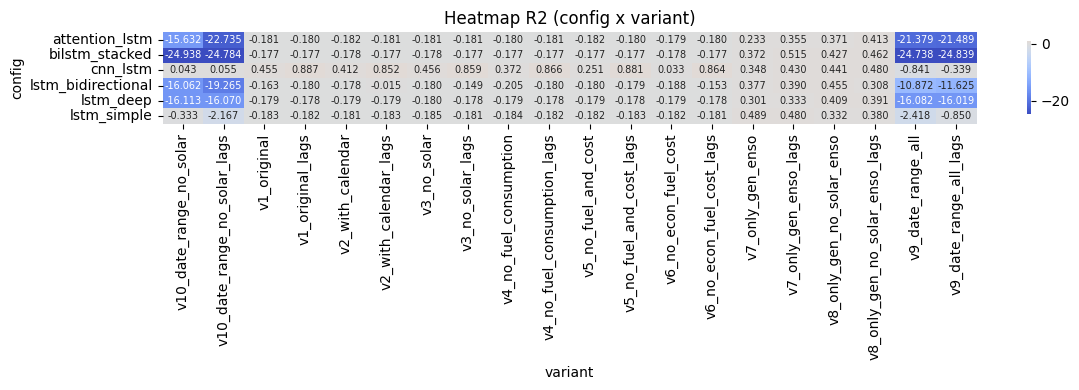

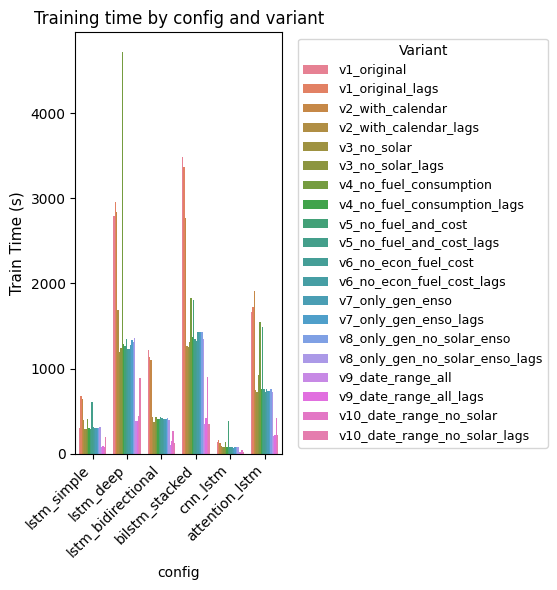

In [8]:
# Build a plotting dataframe from results
try:
    plot_df = results_df.reset_index()
except Exception:
    plot_df = pd.DataFrame(all_results)

plot_df = plot_df.copy()

# Ensure numeric types
for col in ['RMSE', 'R2', 'train_time_s']:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Pivot tables for RMSE and R2 (configs x variants)
if 'RMSE' in plot_df.columns:
    pivot_rmse = plot_df.pivot_table(index='config', columns='variant', values='RMSE')
else:
    pivot_rmse = pd.DataFrame()

if 'R2' in plot_df.columns:
    pivot_r2 = plot_df.pivot_table(index='config', columns='variant', values='R2')
else:
    pivot_r2 = pd.DataFrame()

# Output directory for plots
out_dir = Path('../../data/out/lstm_results/plots')
out_dir.mkdir(parents=True, exist_ok=True)

# ------- GRAPH 1A: HEATMAP RMSE --------
if not pivot_rmse.empty:
    fig_width = min(12, 1 + 0.7 * pivot_rmse.shape[1])
    fig_height = min(10, 1 + 0.5 * pivot_rmse.shape[0])

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot_rmse,
        annot=True,
        fmt='.2f',
        cmap='viridis',
        annot_kws={"size": 7},
        cbar_kws={"shrink": 0.8}
    )
    plt.title('Heatmap RMSE (config x variant)')
    plt.tight_layout()
    plt.savefig(out_dir / 'rmse_heatmap.png')
    plt.show()

# ------- GRAPH 1B: HEATMAP R2 --------
if not pivot_r2.empty:
    fig_width = min(12, 1 + 0.7 * pivot_r2.shape[1])
    fig_height = min(10, 1 + 0.5 * pivot_r2.shape[0])

    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot_r2,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        center=0,
        annot_kws={"size": 7},
        cbar_kws={"shrink": 0.8}
    )
    plt.title('Heatmap R2 (config x variant)')
    plt.tight_layout()
    plt.savefig(out_dir / 'r2_heatmap.png')
    plt.show()

# ------- GRAPH 2: TRAIN TIME --------
if 'train_time_s' in plot_df.columns and not plot_df['train_time_s'].isna().all():
    tt = plot_df.dropna(subset=['train_time_s'])

    config_count = tt['config'].nunique()
    fig_width = min(14, 1 + 0.8 * config_count)

    plt.figure(figsize=(fig_width, 6))
    ax = sns.barplot(data=tt, x='config', y='train_time_s', hue='variant', dodge=True)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylabel('Train Time (s)', fontsize=11)
    plt.title('Training time by config and variant', fontsize=12)
    plt.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left',
               fontsize=9, title_fontsize=10)
    plt.tight_layout()
    plt.savefig(out_dir / 'train_time_by_config_variant.png')
    plt.show()